In [1]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm shap joblib

In [2]:
import os
import re
import string
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    GroupShuffleSplit,
    StratifiedGroupKFold,
    cross_val_score
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

import joblib

RANDOM_STATE = 42

In [3]:
from google.colab import files

uploaded = files.upload()

Saving gossipcop_fake.csv to gossipcop_fake.csv
Saving gossipcop_real.csv to gossipcop_real.csv
Saving politifact_fake.csv to politifact_fake.csv
Saving politifact_real.csv to politifact_real.csv


In [4]:
gossip_fake = pd.read_csv("gossipcop_fake.csv")
gossip_real = pd.read_csv("gossipcop_real.csv")
politifact_fake = pd.read_csv("politifact_fake.csv")
politifact_real = pd.read_csv("politifact_real.csv")

gossip_fake["label"] = 1
gossip_real["label"] = 0
politifact_fake["label"] = 1
politifact_real["label"] = 0

gossip_fake["source"] = "gossipcop"
gossip_real["source"] = "gossipcop"
politifact_fake["source"] = "politifact"
politifact_real["source"] = "politifact"

df = pd.concat(
    [gossip_fake, gossip_real, politifact_fake, politifact_real],
    ignore_index=True
)

print("Combined shape:", df.shape)
df.head()

Combined shape: (23196, 6)


,id,news_url,title,tweet_ids,label,source
0,gossipcop-2493749932,www.dailymail.co.uk/tvshowbiz/article-5874213/...,Did Miley Cyrus and Liam Hemsworth secretly ge...,284329075902926848\t284332744559968256\t284335...,1,gossipcop
1,gossipcop-4580247171,hollywoodlife.com/2018/05/05/paris-jackson-car...,Paris Jackson & Cara Delevingne Enjoy Night Ou...,992895508267130880\t992897935418503169\t992899...,1,gossipcop
2,gossipcop-941805037,variety.com/2017/biz/news/tax-march-donald-tru...,Celebrities Join Tax March in Protest of Donal...,853359353532829696\t853359576543920128\t853359...,1,gossipcop
3,gossipcop-2547891536,www.dailymail.co.uk/femail/article-3499192/Do-...,Cindy Crawford's daughter Kaia Gerber wears a ...,988821905196158981\t988824206556172288\t988825...,1,gossipcop
4,gossipcop-5476631226,variety.com/2018/film/news/list-2018-oscar-nom...,Full List of 2018 Oscar Nominations – Variety,955792793632432131\t955795063925301249\t955798...,1,gossipcop


In [5]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nExact duplicate rows:")
print(df.duplicated().sum())

print("\nClass distribution:")
print(df["label"].value_counts())

print("\nSource distribution:")
print(df["source"].value_counts())

Shape: (23196, 6)

Columns:
['id', 'news_url', 'title', 'tweet_ids', 'label', 'source']

Missing values:
id              0
news_url      330
title           0
tweet_ids    1501
label           0
source          0
dtype: int64

Exact duplicate rows:
0

Class distribution:
label
0    17441
1     5755
Name: count, dtype: int64

Source distribution:
source
gossipcop     22140
politifact     1056
Name: count, dtype: int64


In [6]:
df = df.drop_duplicates().copy()

df["title"] = df["title"].fillna("").astype(str)
df["source"] = df["source"].fillna("unknown").astype(str)

df = df[df["title"].str.strip().ne("")].copy()

df.reset_index(drop=True, inplace=True)

print("Shape after basic cleaning:", df.shape)

Shape after basic cleaning: (23196, 6)


In [7]:
def normalize_title(text):
    text = str(text).lower().strip()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["title_group"] = df["title"].apply(normalize_title)

print("Rows:", len(df))
print("Unique normalized titles:", df["title_group"].nunique())
print("Duplicate-title rows:", df.duplicated("title_group", keep=False).sum())

Rows: 23196
Unique normalized titles: 21713
Duplicate-title rows: 2454


In [8]:
def normalize_title(text):
    text = str(text).lower().strip()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["title_group"] = df["title"].apply(normalize_title)

print("Rows:", len(df))
print("Unique normalized titles:", df["title_group"].nunique())
print("Duplicate-title rows:", df.duplicated("title_group", keep=False).sum())

Rows: 23196
Unique normalized titles: 21713
Duplicate-title rows: 2454


In [11]:
label_conflicts = (
    df.groupby("title_group")["label"]
      .nunique()
      .sort_values(ascending=False)
)

conflicting_titles = label_conflicts[label_conflicts > 1]

print("Normalized titles with conflicting labels:", len(conflicting_titles))

if len(conflicting_titles) > 0:
    conflict_set = set(conflicting_titles.index)
    before = len(df)

    df = df[~df["title_group"].isin(conflict_set)].copy()

    print("Removed rows from conflicting title groups:", before - len(df))
    print("Remaining rows:", len(df))
else:
    print("No conflicting title groups found.")
    print("Remaining rows:", len(df))

Normalized titles with conflicting labels: 125
Removed rows from conflicting title groups: 369
Remaining rows: 22827


In [12]:
df["title_length"] = df["title"].str.len()

df["word_count"] = df["title"].apply(
    lambda x: len(str(x).split())
)

df["avg_word_length"] = df["title"].apply(
    lambda x: (
        np.mean([len(word) for word in str(x).split()])
        if len(str(x).split()) > 0
        else 0
    )
)

df["uppercase_words"] = df["title"].apply(
    lambda x: sum(word.isupper() for word in str(x).split())
)

df["punctuation_count"] = df["title"].apply(
    lambda x: sum(char in string.punctuation for char in str(x))
)

In [13]:
engineered_cols = [
    "title_length",
    "word_count",
    "avg_word_length",
    "uppercase_words",
    "punctuation_count"
]

df[engineered_cols].describe()

,title_length,word_count,avg_word_length,uppercase_words,punctuation_count
count,22827.000000,22827.000000,22827.000000,22827.000000,22827.000000
mean,68.589653,11.209138,5.323081,0.265037,1.504446
std,23.071747,3.944489,1.151121,0.808278,1.649184
min,10.000000,1.000000,2.000000,0.000000,0.000000
25%,55.000000,9.000000,4.750000,0.000000,0.000000
50%,68.000000,11.000000,5.230769,0.000000,1.000000
75%,84.000000,14.000000,5.750000,0.000000,2.000000
max,340.000000,53.000000,70.000000,23.000000,23.000000


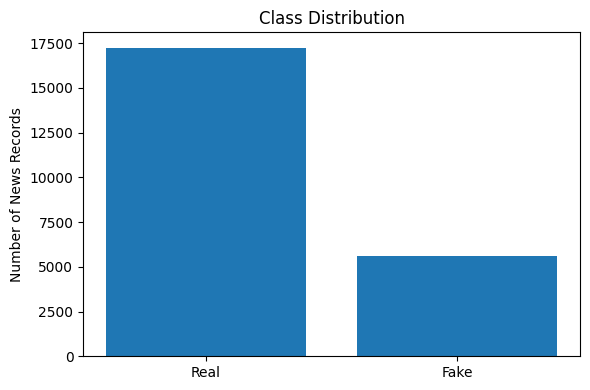

In [14]:
counts = df["label"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Real", "Fake"], [counts.get(0, 0), counts.get(1, 0)])
plt.title("Class Distribution")
plt.ylabel("Number of News Records")
plt.tight_layout()
plt.show()

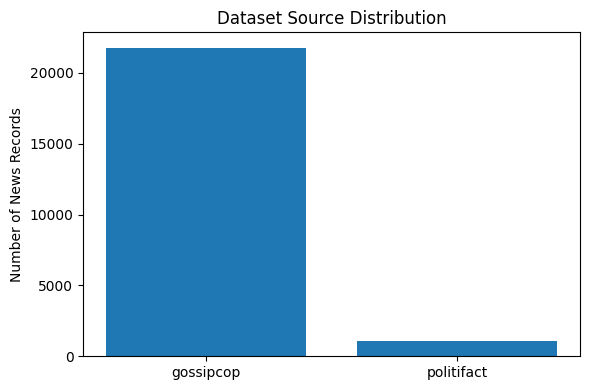

In [15]:
source_counts = df["source"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(source_counts.index, source_counts.values)
plt.title("Dataset Source Distribution")
plt.ylabel("Number of News Records")
plt.tight_layout()
plt.show()

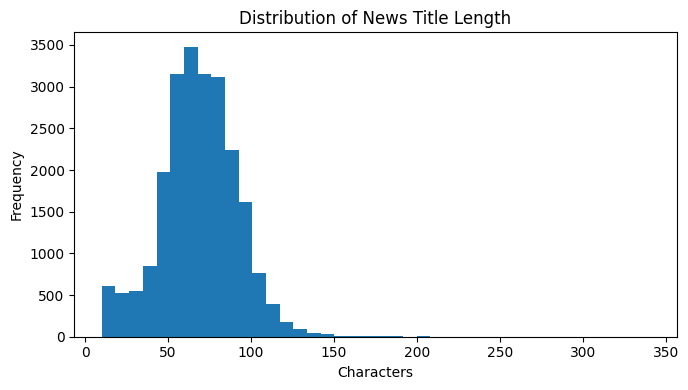

In [16]:
plt.figure(figsize=(7, 4))
plt.hist(df["title_length"], bins=40)
plt.title("Distribution of News Title Length")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

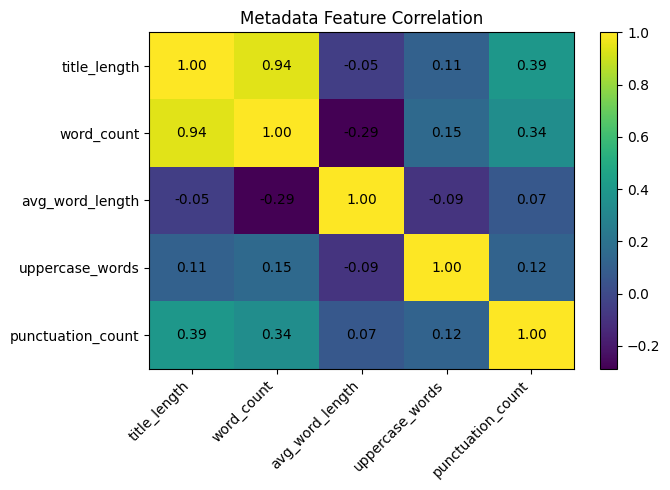

In [17]:
corr_cols = [
    "title_length",
    "word_count",
    "avg_word_length",
    "uppercase_words",
    "punctuation_count"
]

corr = df[corr_cols].corr()

plt.figure(figsize=(7, 5))
plt.imshow(corr, aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(corr_cols)),
    corr_cols,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr_cols)),
    corr_cols
)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Metadata Feature Correlation")
plt.tight_layout()
plt.show()

In [18]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(
    splitter.split(
        X=df,
        y=df["label"],
        groups=df["title_group"]
    )
)

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

print("Training rows:", len(train_df))
print("Testing rows :", len(test_df))

Training rows: 18290
Testing rows : 4537


In [19]:
train_titles = set(train_df["title_group"])
test_titles = set(test_df["title_group"])

overlap = train_titles.intersection(test_titles)

print("Train unique title groups:", len(train_titles))
print("Test unique title groups :", len(test_titles))
print("Overlapping title groups :", len(overlap))

assert len(overlap) == 0, "Leakage detected: title groups overlap!"

Train unique title groups: 17270
Test unique title groups : 4318
Overlapping title groups : 0


In [20]:
print("Training label distribution:")
print(train_df["label"].value_counts(normalize=True))

print("\nTesting label distribution:")
print(test_df["label"].value_counts(normalize=True))

Training label distribution:
label
0    0.755385
1    0.244615
Name: proportion, dtype: float64

Testing label distribution:
label
0    0.755565
1    0.244435
Name: proportion, dtype: float64


In [21]:
TEXT_COL = "title"

NUMERIC_COLS = [
    "title_length",
    "word_count",
    "avg_word_length",
    "uppercase_words",
    "punctuation_count"
]

CATEGORICAL_COLS = [
    "source"
]

TARGET = "label"

In [22]:
text_transformer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=3000,
    ngram_range=(1, 2),
    min_df=2
)

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocessor = ColumnTransformer(
    transformers=[
        ("text", text_transformer, TEXT_COL),
        ("num", numeric_transformer, NUMERIC_COLS),
        ("cat", categorical_transformer, CATEGORICAL_COLS)
    ]
)

In [23]:
y_train = train_df[TARGET]
y_test = test_df[TARGET]

In [26]:
lr_model = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="liblinear",
    random_state=RANDOM_STATE
)

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", lr_model)
])

In [27]:
lr_model = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="liblinear",
    random_state=RANDOM_STATE
)

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", lr_model)
])

In [28]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=30,
    min_samples_split=5,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf_model)
])

In [29]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb_model)
])

In [30]:
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=31,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1
)

lgbm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", lgbm_model)
])

In [31]:
def evaluate_model(name, pipeline, train_df, y_train, test_df, y_test):

    pipeline.fit(train_df, y_train)

    pred = pipeline.predict(test_df)
    prob = pipeline.predict_proba(test_df)[:, 1]

    results = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, prob),
        "Average_Precision": average_precision_score(y_test, prob)
    }

    print("=" * 65)
    print(name)
    print("=" * 65)

    for metric, value in results.items():
        if metric != "Model":
            print(f"{metric:18s}: {value:.4f}")

    print("\nClassification Report")
    print(classification_report(
        y_test,
        pred,
        target_names=["Real", "Fake"]
    ))

    return results, pred, prob

In [32]:
lr_results, lr_pred, lr_prob = evaluate_model(
    "Logistic Regression",
    lr_pipeline,
    train_df,
    y_train,
    test_df,
    y_test
)

Logistic Regression
Accuracy          : 0.8104
Precision         : 0.5881
Recall            : 0.7493
F1                : 0.6590
ROC_AUC           : 0.8660
Average_Precision : 0.7070

Classification Report
              precision    recall  f1-score   support

        Real       0.91      0.83      0.87      3428
        Fake       0.59      0.75      0.66      1109

    accuracy                           0.81      4537
   macro avg       0.75      0.79      0.76      4537
weighted avg       0.83      0.81      0.82      4537



In [33]:
rf_results, rf_pred, rf_prob = evaluate_model(
    "Random Forest",
    rf_pipeline,
    train_df,
    y_train,
    test_df,
    y_test
)

Random Forest
Accuracy          : 0.8199
Precision         : 0.6567
Recall            : 0.5518
F1                : 0.5997
ROC_AUC           : 0.8323
Average_Precision : 0.6576

Classification Report
              precision    recall  f1-score   support

        Real       0.86      0.91      0.88      3428
        Fake       0.66      0.55      0.60      1109

    accuracy                           0.82      4537
   macro avg       0.76      0.73      0.74      4537
weighted avg       0.81      0.82      0.81      4537



In [37]:
xgb_results, xgb_pred, xgb_prob = evaluate_model(
    "XGBoost",
    xgb_pipeline,
    train_df,
    y_train,
    test_df,
    y_test
)

XGBoost
Accuracy          : 0.8270
Precision         : 0.7935
Recall            : 0.3950
F1                : 0.5274
ROC_AUC           : 0.8445
Average_Precision : 0.6793

Classification Report
              precision    recall  f1-score   support

        Real       0.83      0.97      0.89      3428
        Fake       0.79      0.39      0.53      1109

    accuracy                           0.83      4537
   macro avg       0.81      0.68      0.71      4537
weighted avg       0.82      0.83      0.80      4537



In [34]:
lgbm_results, lgbm_pred, lgbm_prob = evaluate_model(
    "LightGBM",
    lgbm_pipeline,
    train_df,
    y_train,
    test_df,
    y_test
)

LightGBM
Accuracy          : 0.8179
Precision         : 0.6221
Recall            : 0.6501
F1                : 0.6358
ROC_AUC           : 0.8442
Average_Precision : 0.6815

Classification Report
              precision    recall  f1-score   support

        Real       0.89      0.87      0.88      3428
        Fake       0.62      0.65      0.64      1109

    accuracy                           0.82      4537
   macro avg       0.75      0.76      0.76      4537
weighted avg       0.82      0.82      0.82      4537



In [38]:
results_df = pd.DataFrame([
    lr_results,
    rf_results,
    xgb_results,
    lgbm_results
])

metric_cols = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC",
    "Average_Precision"
]

results_df[metric_cols] = results_df[metric_cols].round(4)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Average_Precision
0,Logistic Regression,0.8104,0.5881,0.7493,0.6590,0.8660,0.7070
1,Random Forest,0.8199,0.6567,0.5518,0.5997,0.8323,0.6576
2,XGBoost,0.8270,0.7935,0.3950,0.5274,0.8445,0.6793
3,LightGBM,0.8179,0.6221,0.6501,0.6358,0.8442,0.6815


In [39]:
results_df.to_csv(
    "corrected_model_results.csv",
    index=False
)

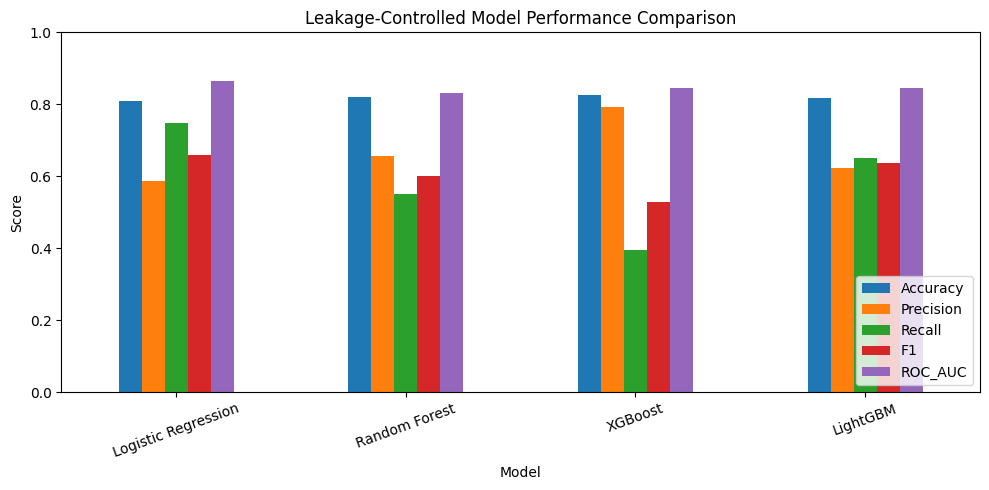

In [40]:
plot_df = results_df.set_index("Model")

ax = plot_df[
    ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Leakage-Controlled Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

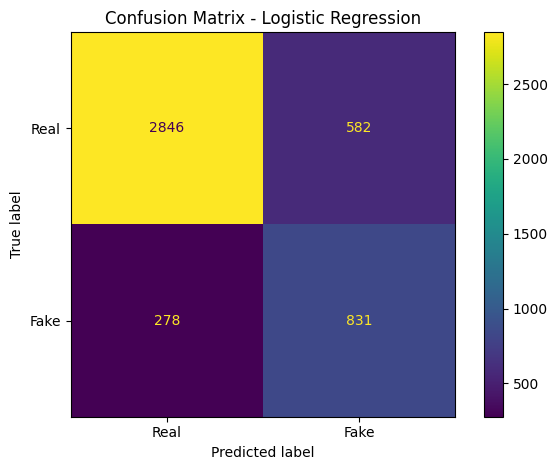

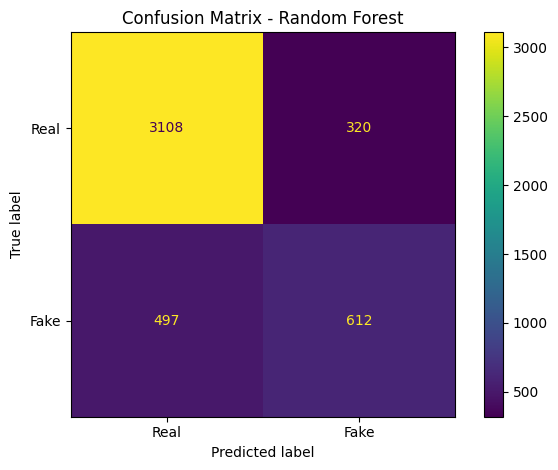

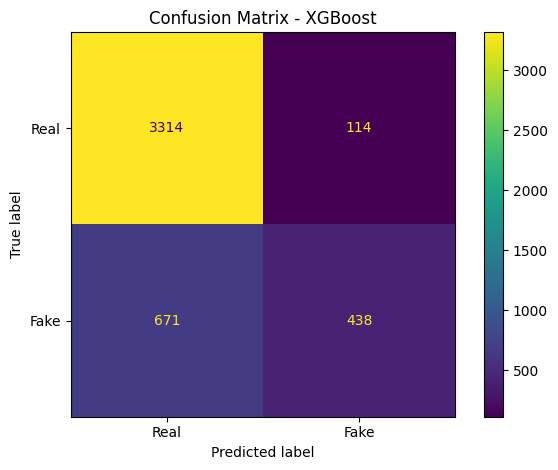

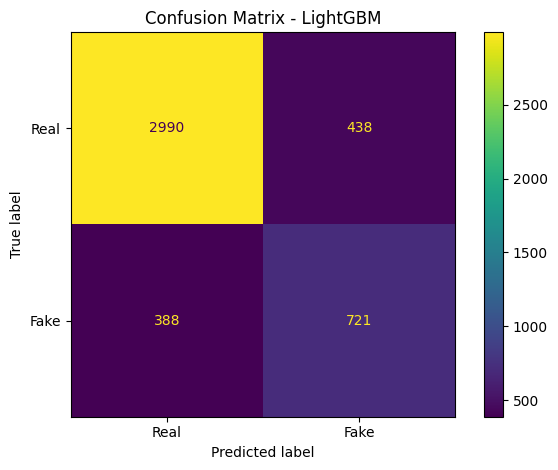

In [41]:
models_output = {
    "Logistic Regression": lr_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred,
    "LightGBM": lgbm_pred
}

for name, pred in models_output.items():

    cm = confusion_matrix(y_test, pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Real", "Fake"]
    )

    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()

<Figure size 700x600 with 0 Axes>

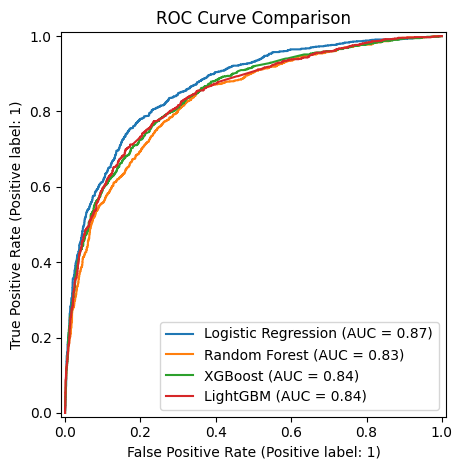

In [42]:
plt.figure(figsize=(7, 6))

RocCurveDisplay.from_predictions(
    y_test,
    lr_prob,
    name=f"Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    rf_prob,
    name="Random Forest",
    ax=plt.gca()
)

RocCurveDisplay.from_predictions(
    y_test,
    xgb_prob,
    name="XGBoost",
    ax=plt.gca()
)

RocCurveDisplay.from_predictions(
    y_test,
    lgbm_prob,
    name="LightGBM",
    ax=plt.gca()
)

plt.title("ROC Curve Comparison")
plt.tight_layout()
plt.show()

<Figure size 700x600 with 0 Axes>

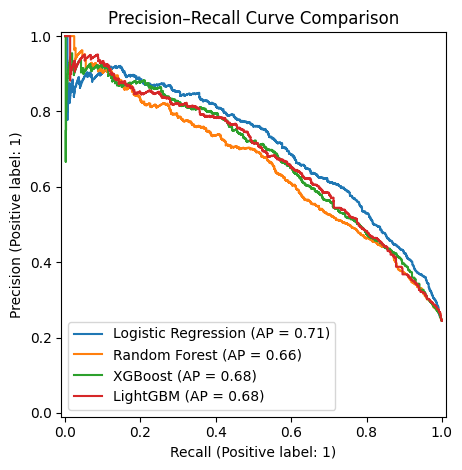

In [43]:
plt.figure(figsize=(7, 6))

PrecisionRecallDisplay.from_predictions(
    y_test,
    lr_prob,
    name="Logistic Regression"
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    rf_prob,
    name="Random Forest",
    ax=plt.gca()
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    xgb_prob,
    name="XGBoost",
    ax=plt.gca()
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    lgbm_prob,
    name="LightGBM",
    ax=plt.gca()
)

plt.title("Precision–Recall Curve Comparison")
plt.tight_layout()
plt.show()

In [44]:
cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [45]:
pipelines = {
    "Logistic Regression": lr_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline,
    "LightGBM": lgbm_pipeline
}

cv_results = []

for name, model_pipeline in pipelines.items():

    scores = cross_val_score(
        model_pipeline,
        train_df,
        y_train,
        groups=train_df["title_group"],
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Mean_CV_F1": scores.mean(),
        "Std_CV_F1": scores.std(),
        "Fold_1": scores[0],
        "Fold_2": scores[1],
        "Fold_3": scores[2],
        "Fold_4": scores[3],
        "Fold_5": scores[4]
    })

    print(name)
    print("Fold F1:", np.round(scores, 4))
    print("Mean F1:", round(scores.mean(), 4))
    print("Std F1 :", round(scores.std(), 4))
    print()

Logistic Regression
Fold F1: [0.6634 0.667  0.6593 0.6441 0.6475]
Mean F1: 0.6562
Std F1 : 0.0089

Random Forest
Fold F1: [0.6263 0.6022 0.5893 0.6    0.5955]
Mean F1: 0.6027
Std F1 : 0.0126

XGBoost
Fold F1: [0.5519 0.5272 0.5251 0.4992 0.5471]
Mean F1: 0.5301
Std F1 : 0.0187

LightGBM
Fold F1: [0.6223 0.6355 0.6269 0.6262 0.6102]
Mean F1: 0.6242
Std F1 : 0.0082



In [46]:
cv_results_df = pd.DataFrame(cv_results)

cv_results_df.round(4)

,Model,Mean_CV_F1,Std_CV_F1,Fold_1,Fold_2,Fold_3,Fold_4,Fold_5
0,Logistic Regression,0.6562,0.0089,0.6634,0.6670,0.6593,0.6441,0.6475
1,Random Forest,0.6027,0.0126,0.6263,0.6022,0.5893,0.6000,0.5955
2,XGBoost,0.5301,0.0187,0.5519,0.5272,0.5251,0.4992,0.5471
3,LightGBM,0.6242,0.0082,0.6223,0.6355,0.6269,0.6262,0.6102


In [47]:
cv_results_df.to_csv(
    "grouped_cross_validation_results.csv",
    index=False
)

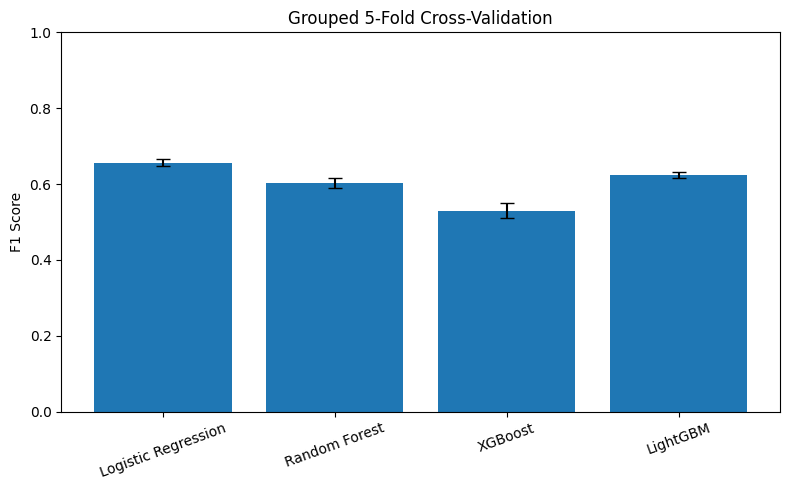

In [48]:
plt.figure(figsize=(8, 5))

plt.bar(
    cv_results_df["Model"],
    cv_results_df["Mean_CV_F1"],
    yerr=cv_results_df["Std_CV_F1"],
    capsize=5
)

plt.ylabel("F1 Score")
plt.title("Grouped 5-Fold Cross-Validation")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [49]:
best_row = results_df.sort_values(
    by="F1",
    ascending=False
).iloc[0]

best_model_name = best_row["Model"]

print("Best test-set model by F1:", best_model_name)
print(best_row)

Best test-set model by F1: Logistic Regression
Model                Logistic Regression
Accuracy                          0.8104
Precision                         0.5881
Recall                            0.7493
F1                                 0.659
ROC_AUC                            0.866
Average_Precision                  0.707
Name: 0, dtype: object


In [50]:
best_pipeline = lgbm_pipeline

best_pipeline.fit(
    train_df,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=3000,
                                                                  min_df=2,
                                                                  ngram_range=(1,
                                                                               2),
                                                                  stop_words='english'),
                                                  'title'),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['title_length', 'word_count',
                                                   'avg_word_length',
                                                   'uppercase_words',
                                                   'punctuation_count']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['source'])])),
                ('model',
                 LGBMClassifier(class_weight='balanced', learning_rate=0.05,
                                max_depth=8, n_estimators=300, n_jobs=-1,
                                random_state=42, verbosity=-1))])

In [51]:
fitted_preprocessor = best_pipeline.named_steps["preprocessor"]
fitted_model = best_pipeline.named_steps["model"]

In [52]:
X_test_transformed = fitted_preprocessor.transform(test_df)

print("Transformed test shape:", X_test_transformed.shape)

Transformed test shape: (4537, 3007)


In [53]:
feature_names = fitted_preprocessor.get_feature_names_out()

feature_names[:20], len(feature_names)

(array(['text__000', 'text__10', 'text__10 things', 'text__10 years',
        'text__100', 'text__11', 'text__12', 'text__13',
        'text__13 reasons', 'text__14', 'text__15', 'text__16', 'text__17',
        'text__19', 'text__20', 'text__20 years', 'text__2011',
        'text__2016', 'text__2017', 'text__2017 billboard'], dtype=object),
 3007)

In [54]:
import shap

sample_size = min(500, X_test_transformed.shape[0])

X_shap = X_test_transformed[:sample_size]

if hasattr(X_shap, "toarray"):
    X_shap_dense = X_shap.toarray()
else:
    X_shap_dense = X_shap

explainer = shap.TreeExplainer(fitted_model)

shap_values = explainer.shap_values(X_shap_dense)

In [55]:
if isinstance(shap_values, list):
    shap_for_plot = shap_values[1]
else:
    shap_for_plot = shap_values

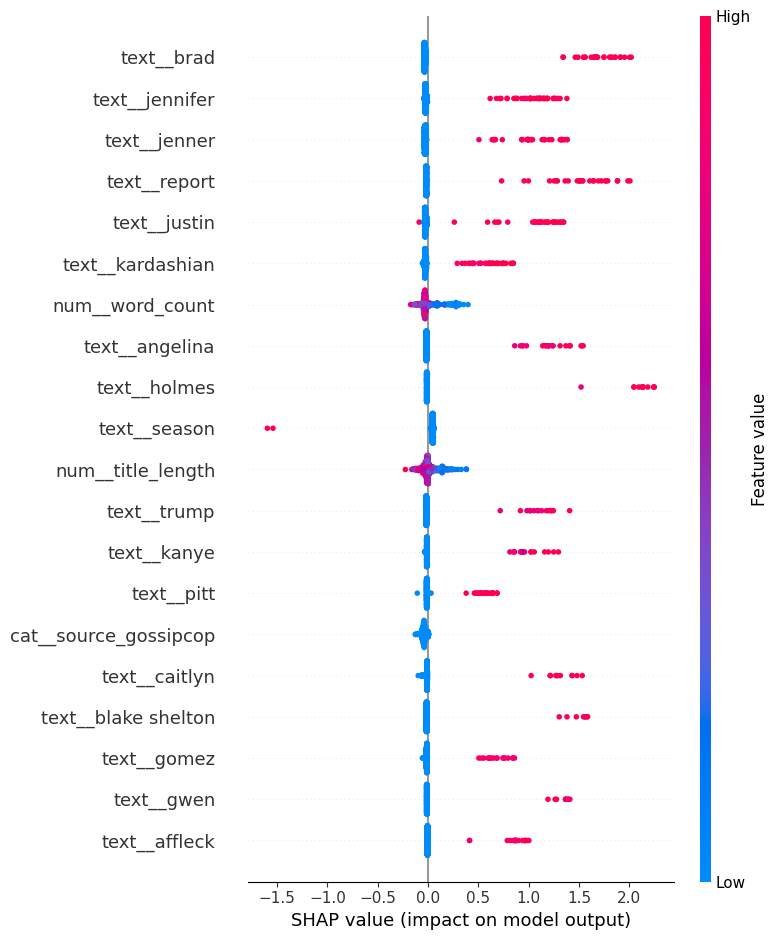

In [56]:
shap.summary_plot(
    shap_for_plot,
    X_shap_dense,
    feature_names=feature_names,
    max_display=20
)

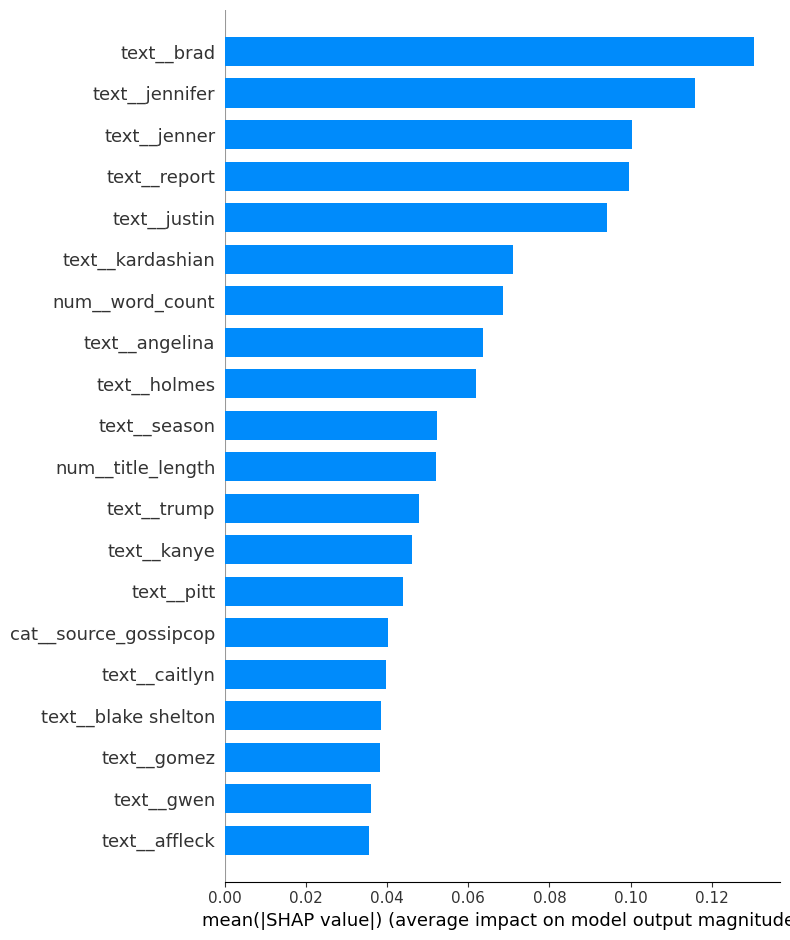

In [57]:
shap.summary_plot(
    shap_for_plot,
    X_shap_dense,
    feature_names=feature_names,
    plot_type="bar",
    max_display=20
)

In [58]:
mean_abs_shap = np.abs(shap_for_plot).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": mean_abs_shap
})

shap_importance = shap_importance.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
)

shap_importance.head(20)

,Feature,Mean_Absolute_SHAP
357,text__brad,0.130345
1344,text__jennifer,0.115870
1342,text__jenner,0.100255
2224,text__report,0.099708
1419,text__justin,0.094173
1433,text__kardashian,0.071095
3001,num__word_count,0.068641
147,text__angelina,0.063645
1226,text__holmes,0.061917
2370,text__season,0.052240


In [59]:
shap_importance.to_csv(
    "corrected_shap_feature_importance.csv",
    index=False
)

In [60]:
probabilities = {
    "Logistic Regression": lr_prob,
    "Random Forest": rf_prob,
    "XGBoost": xgb_prob,
    "LightGBM": lgbm_prob
}

predictions = {
    "Logistic Regression": lr_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred,
    "LightGBM": lgbm_pred
}

best_pred = predictions[best_model_name]
best_prob = probabilities[best_model_name]

In [61]:
error_df = test_df[
    ["title", "source", "label"]
].copy()

error_df["prediction"] = best_pred
error_df["probability_fake"] = best_prob

error_df["correct"] = (
    error_df["label"] == error_df["prediction"]
)

errors = error_df[~error_df["correct"]].copy()

print("Total test errors:", len(errors))
errors.head(20)

Total test errors: 860


,title,source,label,prediction,probability_fake,correct
5,Here's What Really Happened When JFK Jr. Met P...,gossipcop,1,0,0.292802,False
16,He’s Hired! Ben Affleck Enlists Best Friend Ma...,gossipcop,1,0,0.444895,False
17,Full statement: John McCain to vote no on Grah...,gossipcop,1,0,0.104764,False
51,"Biggest Engagement Rings Of 2017 — Cardi B, Ca...",gossipcop,1,0,0.071772,False
68,Drew Barrymore! Gisele Bündchen! Miley Cyrus! ...,gossipcop,1,0,0.404820,False
96,Hollywood's Expectant Moms: Inside Mindy Kalin...,gossipcop,1,0,0.186046,False
100,Throwback Alert! Relive Pippa Middleton's Scen...,gossipcop,1,0,0.136981,False
133,Tom Selleck Weighs In on the 'Magnum P.I.' Reb...,gossipcop,1,0,0.387904,False
135,Teri Hatcher Broke And Homeless,gossipcop,1,0,0.205518,False
138,Katy Perry ends six year beef with Calvin Harris,gossipcop,1,0,0.462861,False


In [62]:
false_negatives = errors[
    (errors["label"] == 1) &
    (errors["prediction"] == 0)
]

print("Fake news incorrectly classified as real:")
display(false_negatives.head(15))

Fake news incorrectly classified as real:


,title,source,label,prediction,probability_fake,correct
5,Here's What Really Happened When JFK Jr. Met P...,gossipcop,1,0,0.292802,False
16,He’s Hired! Ben Affleck Enlists Best Friend Ma...,gossipcop,1,0,0.444895,False
17,Full statement: John McCain to vote no on Grah...,gossipcop,1,0,0.104764,False
51,"Biggest Engagement Rings Of 2017 — Cardi B, Ca...",gossipcop,1,0,0.071772,False
68,Drew Barrymore! Gisele Bündchen! Miley Cyrus! ...,gossipcop,1,0,0.404820,False
96,Hollywood's Expectant Moms: Inside Mindy Kalin...,gossipcop,1,0,0.186046,False
100,Throwback Alert! Relive Pippa Middleton's Scen...,gossipcop,1,0,0.136981,False
133,Tom Selleck Weighs In on the 'Magnum P.I.' Reb...,gossipcop,1,0,0.387904,False
135,Teri Hatcher Broke And Homeless,gossipcop,1,0,0.205518,False
138,Katy Perry ends six year beef with Calvin Harris,gossipcop,1,0,0.462861,False


In [63]:
false_positives = errors[
    (errors["label"] == 0) &
    (errors["prediction"] == 1)
]

print("Real news incorrectly classified as fake:")
display(false_positives.head(15))

Real news incorrectly classified as fake:


,title,source,label,prediction,probability_fake,correct
5324,Kylie Jenner refusing to discuss Tyga on Life ...,gossipcop,0,1,0.677215,False
5354,Jim Carrey lawsuit: Unearthed note from ex-gir...,gossipcop,0,1,0.606060,False
5356,"Prepare to See Joe Alwyn in, Well, Everything",gossipcop,0,1,0.524381,False
5359,Colin Jost,gossipcop,0,1,0.550328,False
5380,Darren Criss Is Engaged! Actor Proposes to Gir...,gossipcop,0,1,0.556345,False
5436,Kim Kardashian and Kanye West's surrogate reve...,gossipcop,0,1,0.918139,False
5453,Why Jennifer Lopez and Alex Rodriguez Are Rela...,gossipcop,0,1,0.818686,False
5456,Jenna Dewan Tatum Denies Legendary Britney Spe...,gossipcop,0,1,0.630416,False
5519,Prince Harry Takes Meghan Markle for Tea at th...,gossipcop,0,1,0.770504,False
5524,Sarah Silverman and Michael Sheen Broke Up Bec...,gossipcop,0,1,0.698466,False


In [64]:
best_test_results = test_df[
    ["source", "label"]
].copy()

best_test_results["prediction"] = best_pred

In [65]:
source_eval = []

for source_name, group in best_test_results.groupby("source"):

    source_eval.append({
        "Source": source_name,
        "N": len(group),
        "Accuracy": accuracy_score(
            group["label"],
            group["prediction"]
        ),
        "Precision": precision_score(
            group["label"],
            group["prediction"],
            zero_division=0
        ),
        "Recall": recall_score(
            group["label"],
            group["prediction"],
            zero_division=0
        ),
        "F1": f1_score(
            group["label"],
            group["prediction"],
            zero_division=0
        )
    })

source_eval_df = pd.DataFrame(source_eval)

source_eval_df.round(4)

,Source,N,Accuracy,Precision,Recall,F1
0,gossipcop,4340,0.8191,0.5925,0.7427,0.6591
1,politifact,197,0.6193,0.5455,0.8276,0.6575


In [66]:
joblib.dump(
    lr_pipeline,
    "corrected_logistic_regression_pipeline.pkl"
)

joblib.dump(
    rf_pipeline,
    "corrected_random_forest_pipeline.pkl"
)

joblib.dump(
    xgb_pipeline,
    "corrected_xgboost_pipeline.pkl"
)

joblib.dump(
    lgbm_pipeline,
    "corrected_lightgbm_pipeline.pkl"
)

print("Corrected pipelines saved.")

Corrected pipelines saved.


In [67]:
audit = pd.DataFrame({
    "Check": [
        "TF-IDF fitted before split",
        "Duplicate title groups across train/test",
        "Final tweet count used as predictor",
        "Unsupported season feature",
        "Preprocessing fitted inside pipeline",
        "Held-out test set used for final evaluation"
    ],
    "Corrected Pipeline": [
        "No",
        "No",
        "No",
        "No",
        "Yes",
        "Yes"
    ]
})

audit

,Check,Corrected Pipeline
0,TF-IDF fitted before split,No
1,Duplicate title groups across train/test,No
2,Final tweet count used as predictor,No
3,Unsupported season feature,No
4,Preprocessing fitted inside pipeline,Yes
5,Held-out test set used for final evaluation,Yes


In [68]:
model_dataset_cols = [
    "title",
    "source",
    "label",
    "title_group",
    "title_length",
    "word_count",
    "avg_word_length",
    "uppercase_words",
    "punctuation_count"
]

df[model_dataset_cols].to_csv(
    "corrected_fakenews_classification_dataset.csv",
    index=False
)

print("Corrected modelling dataset saved.")

Corrected modelling dataset saved.
